### **Comparando Anotações de um Mesmo Frame**

In [1]:
import sys
sys.path.append('../')

In [2]:
import pandas as pd
import os
import numpy as np
import random
import torch
import math
import matplotlib.pyplot as plt
from scipy import stats
import cv2
import operator
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path

from src.data_extraction.labels import get_label_metadata
from src.data_extraction.attributions import get_attributions_metadata
from src.data_extraction.video_frame import create_video_frame_metadata_from_label_and_attributions
from src.create_folders import get_frame_from_video
from src.target.points import load_points
from src.data_comparison import *

In [3]:
def set_seed(seed_value=42):
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)

### **Importando Dados**

In [4]:
labels_dir = '..\\data\\rotulos\\anotacoes-tecgraf\\'
frames_dir = '..\\data\\frames\\'
videos_dir = '..\\data\\videos\\' 

In [5]:
# Importando dados:
attribution_metadata_df = get_attributions_metadata(labels_dir)
labels_metadata_df = get_label_metadata(labels_dir)

video_frame_metadata_df = create_video_frame_metadata_from_label_and_attributions(
    label_metadata=labels_metadata_df,
    attributions_metadata=attribution_metadata_df
)
video_frame_metadata_df

The results CSV is missing the following required columns: {'Height', 'BX', 'Width', 'BY'}. Check the file at ..\data\rotulos\anotacoes-tecgraf\batch-2\VR\v98_f45\Results.csv.
The results CSV is missing the following required columns: {'Angle'}. Check the file at ..\data\rotulos\anotacoes-tecgraf\batch-3\CS\v101_f74\Results.csv.
Shape of attributions metadata df: (2000, 5)
Shape of label metadata df: (1985, 7)
Shape of labeled frames df: (2000, 9)


,batch,labeler,video_frame,video_id,frame_id,file_path,has_mask,has_points
0,1,AM,v33_f24,33,24,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
1,1,AM,v54_f127,54,127,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
2,1,AM,v74_f65,74,65,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
3,1,BB,v16_f122,16,122,..\data\rotulos\anotacoes-tecgraf\batch-1\BB\v...,True,True
4,1,BB,v66_f166,66,166,..\data\rotulos\anotacoes-tecgraf\batch-1\BB\v...,True,True
...,...,...,...,...,...,...,...,...
1995,5,VR,v70_f137,70,137,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1996,5,VR,v76_f80,76,80,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1997,5,VR,v78_f213,78,213,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1998,5,VR,v89_f118,89,118,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True


In [6]:
# Checa se existem pasta não criadas
def create_missing_label_dirs(
    video_frame_metadata_df: pd.DataFrame,
    data_root: str = r"..",
) -> pd.DataFrame:

    required = {"file_path", "batch", "labeler", "video_frame", "video_id", "frame_id", "has_mask", "has_points"}
    missing = required - set(video_frame_metadata_df.columns)
    if missing:
        raise ValueError(f"Colunas ausentes no DataFrame: {missing}")

    df = video_frame_metadata_df.copy()
    mask_nan = df["file_path"].isna()
    n_missing = mask_nan.sum()

    if n_missing == 0:
        print("Nenhum file_path ausente. Nada a criar.")
        return df

    print(f"Criando pastas para {n_missing} frame(s) com file_path ausente...")

    created, already_existed = 0, 0
    for idx, row in df[mask_nan].iterrows():
        folder = str(
            Path(data_root)
            / "data"
            / "rotulos"
            / "anotacoes-tecgraf"
            / f"batch-{row['batch']}"
            / str(row["labeler"])
            / str(row["video_frame"])
        )
        p = Path(folder)
        if p.exists():
            already_existed += 1
        else:
            p.mkdir(parents=True, exist_ok=True)
            created += 1

        df.at[idx, "file_path"] = folder

    print(f"  Criadas:          {created}")
    print(f"  Já existiam:      {already_existed}")
    print(f"  file_path total preenchido: {n_missing}")
    return df

video_frame_metadata_df = create_missing_label_dirs(video_frame_metadata_df, data_root = r"..")

Criando pastas para 15 frame(s) com file_path ausente...
  Criadas:          15
  Já existiam:      0
  file_path total preenchido: 15


### **Verifica dimensões**

In [6]:
# Verficando Dimensão/Posição dos Rótulos
video_frame_metadata_df.apply(verifica_dimensoes, axis =1, args = (videos_dir,))
print("Primeira Etapa Concluída")


Resolução de Máscara Incorreta
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Máscara Rotulada: (1024, 1024, 3)
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Posição de Ponto Inválida
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Pontos Marcados: [590. 428.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Posição de Ponto Inválida
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Pontos Marcados: [631. 597.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Resolução de Máscara Incorreta
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Máscara Rotulada: (1024, 1024, 3)
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-4\AM\v1_f84

Posição de Ponto Inválida
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Pontos Marcados: [589. 428.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-4\AM\v1_f84

Posição de Ponto Inválida
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Pontos Marcados: [632. 596.]
	Label Folder: ..\data\rotu

### **Checa por Máscaras Invertidas**

In [7]:
# Checando Máscaras Invertidas
video_frame_metadata_df.apply(check_inverted_masks, axis =1)
print("Checagem concluída!")

Checagem concluída!


In [8]:
# Consertando Máscaras Invertidas
substituir_definitivamente = False
if substituir_definitivamente:
    video_frame_metadata_df.apply(correct_inverted_masks, axis = 1)
    print("Correção de Máscaras Invertidas Concluída!")


### **Visualizando Anotações de um Mesmo Frame**

In [ ]:
# Visualizando Todas as Marcações de Pontos
output_folder = r"..\\fig\\comparison\\point"

for batch in video_frame_metadata_df["batch"].unique():
    df_batch = video_frame_metadata_df.loc[video_frame_metadata_df["batch"] == batch]
    video_frame_unique = df_batch["video_frame"].unique()
    outpu_folder_batch = os.path.join(output_folder,f"batch-{batch}")
    for video_frame in video_frame_unique:
        df_video_frame = video_frame_metadata_df.loc[video_frame_metadata_df["video_frame"] == video_frame].reset_index()
        plot_coherence_points(df_video_frame, videos_dir, outpu_folder_batch)

In [ ]:
# Visualizando Marcações de Máscaras
output_folder = r"..\\fig\\comparison\\mask"

for batch in video_frame_metadata_df["batch"].unique():
    df_batch = video_frame_metadata_df.loc[video_frame_metadata_df["batch"] == batch]
    video_frame_unique = df_batch["video_frame"].unique()
    outpu_folder_batch = os.path.join(output_folder,f"batch-{batch}")
    for video_frame in video_frame_unique:
        df_video_frame = video_frame_metadata_df.loc[video_frame_metadata_df["video_frame"] == video_frame].reset_index()
        plot_coherence_masks(df_video_frame, videos_dir, outpu_folder_batch)

### **Validando Métricas em um Mesmo Frame**

In [6]:
# Métricas para Pontos em um mesmo frame
dfMetricPoint = metric_coherence_points(video_frame_metadata_df, videos_dir)
dfMetricPoint

,distance_C2,distance_C4,distance_points,difference_length,labeler_1,labeler_2,video_frame
0,0.035386,0.012733,0.048119,0.011966,AM,CS,v33_f24
1,0.003088,0.003906,0.006994,0.003656,AM,VC,v54_f127
2,0.020601,0.013567,0.034167,0.001539,AM,VC,v74_f65
3,0.006176,0.007627,0.013804,0.002876,BB,CS,v16_f122
4,0.009766,0.007042,0.016808,0.012352,BB,VR,v66_f166
...,...,...,...,...,...,...,...
903,0.000977,0.003521,0.004498,0.002664,VC,VR,v68_f134
904,0.001953,0.006176,0.008129,0.003922,VC,VR,v70_f137
905,0.002930,0.013283,0.016212,0.001038,VC,VR,v78_f213
906,0.000000,0.013811,0.013811,0.006442,VC,VR,v89_f118


In [7]:
# Métricas para Máscaras em um mesmo frame
dfMetricMask = metric_coherence_masks(video_frame_metadata_df)
dfMetricMask

,dice,iou,area_diff,labeler_1,labeler_2,video_frame
0,0.874139,0.776418,0.171177,AM,CS,v33_f24
1,0.916996,0.846716,0.039410,AM,VC,v54_f127
2,0.898637,0.815931,0.030135,AM,VC,v74_f65
3,0.745113,0.593769,0.556309,BB,CS,v16_f122
4,0.774793,0.632378,0.491141,BB,VC,v83_f29
...,...,...,...,...,...,...
893,0.925885,0.861997,0.083831,VC,VR,v68_f134
894,0.832225,0.712659,0.195507,VC,VR,v70_f137
895,0.886689,0.796443,0.027639,VC,VR,v78_f213
896,0.926951,0.863848,0.023625,VC,VR,v89_f118


### **Analisando Rótulos em um Mesmo Frame**

In [ ]:
# Mostrando Gráficos e Imagens de Interesse - Pontos
plot_comparison(dfMetricPoint, ["distance_C2", "distance_C4", "distance_points", "difference_length"])
print(dfMetricPoint[["distance_C2", "distance_C4", "distance_points", "difference_length"]].describe())
get_annotations(video_frame_metadata_df,
                dfMetric = dfMetricPoint,
                col_metric = "distance_points",
                videos_dir = videos_dir,
                threshold = 0.1,
                op = operator.ge,
                dtype = "points")

In [ ]:
# Mostrando Gráficos e Imagens de Interesse - Máscaras
plot_comparison(dfMetricMask, ["dice", "iou", "area_diff"])
print(dfMetricMask[["dice", "iou", "area_diff"]].describe())
get_annotations(video_frame_metadata_df,
                dfMetric = dfMetricMask,
                col_metric = "iou",
                videos_dir = videos_dir,
                threshold = 0.80,
                op = operator.le,
                dtype = "mask")

### **Métricas entre Anotadores**

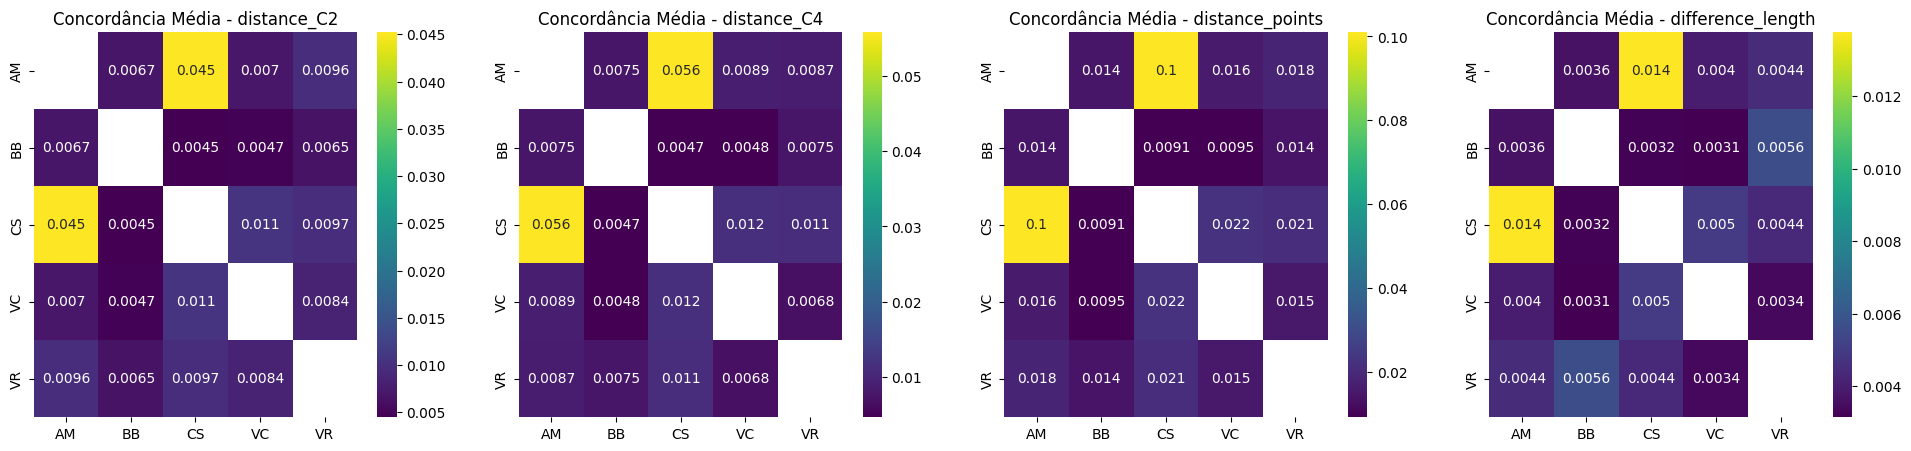

In [8]:
# Matriz de Confusão - Pontos
plot_metric_matrix(dfMetricPoint, ["distance_C2", "distance_C4", "distance_points", "difference_length"])

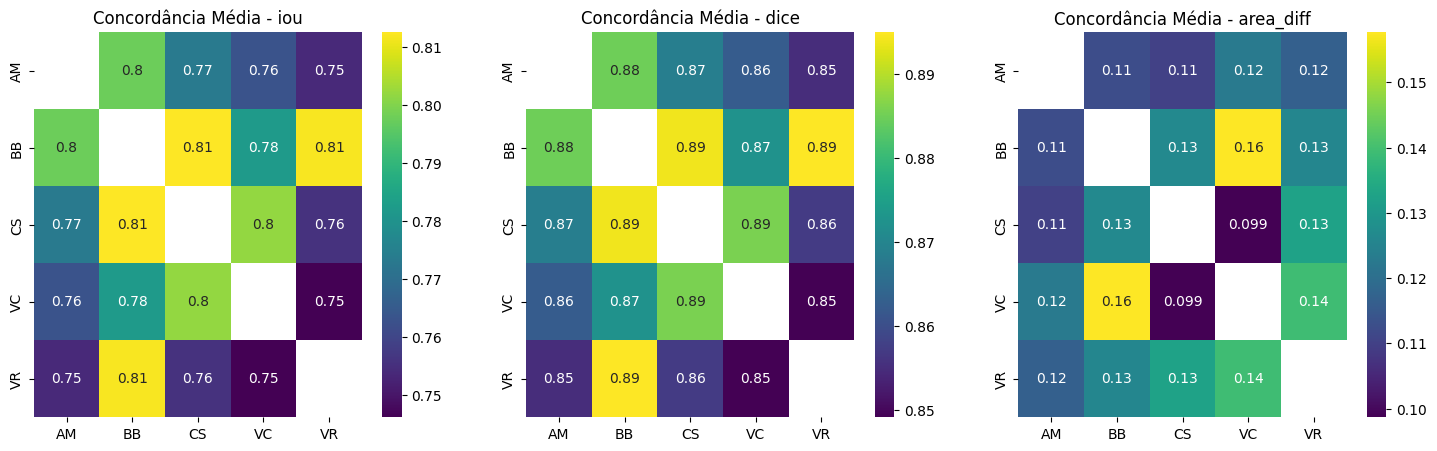

In [9]:
# Matriz de Confusão - Máscara
plot_metric_matrix(dfMetricMask, ["iou", "dice", "area_diff"])

### **Classificando Imagens a serem rotuladas novamente**

In [19]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.widgets as mwidgets
import cv2
import tkinter as tk
from tkinter import ttk


# ── Constantes de cor ─────────────────────────────────────────────────────────
_DARK_BG    = "#1e1e1e"
_DARK_TEXT  = "white"
_LIGHT_BG   = "white"
_LIGHT_TEXT = "black"


def _save_csvs(relabel: dict, motivos: dict, output_csv_dir: str, label_type: str):
    """Salva (ou sobrescreve) o CSV de cada rotulador imediatamente."""
    os.makedirs(output_csv_dir, exist_ok=True)
    for labeler, frames_set in relabel.items():
        rows = [
            {"video_frame": vf, "rotulo": label_type, "motivo": motivos.get(labeler, {}).get(vf, "")}
            for vf in sorted(frames_set)
        ]
        df_out = pd.DataFrame(rows, columns=["video_frame", "rotulo", "motivo"])
        csv_path = os.path.join(output_csv_dir, f"relabel_{labeler}_{label_type}.csv")
        df_out.to_csv(csv_path, index=False)


def _apply_clahe(frame: np.ndarray, clip_limit: float = 2.0, tile_grid: tuple = (8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    if frame.ndim == 2:
        return clahe.apply(frame)
    else:
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        lab[..., 0] = clahe.apply(lab[..., 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def _compute_dice_iou(mask1: np.ndarray, mask2: np.ndarray):
    m1 = mask1 > 0
    m2 = mask2 > 0
    intersection = np.logical_and(m1, m2).sum()
    union        = np.logical_or(m1, m2).sum()
    sum_masks    = m1.sum() + m2.sum()
    dice = (2 * intersection / sum_masks) if sum_masks > 0 else float("nan")
    iou  = (intersection / union)         if union > 0       else float("nan")
    return dice, iou


def _compute_point_distance(pts1: np.ndarray, pts2: np.ndarray) -> float:
    mid1 = (pts1[0] + pts1[1]) / 2
    mid2 = (pts2[0] + pts2[1]) / 2
    return math.sqrt((mid1[0] - mid2[0]) ** 2 + (mid1[1] - mid2[1]) ** 2)


def _bbox_from_points(all_pts: list, padding: int = 80):
    all_coords = np.concatenate(all_pts, axis=0)
    x_min, y_min = all_coords.min(axis=0)
    x_max, y_max = all_coords.max(axis=0)
    return (x_min - padding, x_max + padding,
            y_min - padding, y_max + padding)


def _bbox_from_masks(all_masks: list, padding: int = 80):
    union = np.zeros_like(all_masks[0], dtype=bool)
    for m in all_masks:
        union |= (m > 0)
    rows = np.any(union, axis=1)
    cols = np.any(union, axis=0)
    if not rows.any():
        return None
    y_min, y_max = np.where(rows)[0][[0, -1]]
    x_min, x_max = np.where(cols)[0][[0, -1]]
    return (x_min - padding, x_max + padding,
            y_min - padding, y_max + padding)


def _apply_zoom(ax, bbox, frame_shape, zoom_on: bool):
    if not zoom_on or bbox is None:
        ax.set_xlim(0, frame_shape[1])
        ax.set_ylim(frame_shape[0], 0)
        return
    h, w = frame_shape[:2]
    x_min, x_max, y_min, y_max = bbox
    ax.set_xlim(max(0, x_min), min(w, x_max))
    ax.set_ylim(min(h, y_max), max(0, y_min))


def _set_label_below(ax, text: str, color: str, fontsize: int = 9):
    """
    Coloca o texto abaixo do subplot mesmo com axis('off').
    Usa ax.text em coordenadas de eixo normalizadas (0.5, -0.02).
    Remove textos anteriores do mesmo tipo para evitar acúmulo.
    """
    # Remove textos anteriores marcados como subtítulo
    for child in ax.texts:
        if getattr(child, "_is_subtitle", False):
            child.remove()
    t = ax.text(
        0.5, -0.02, text,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=fontsize,
        color=color,
        wrap=True,
    )
    t._is_subtitle = True  # marca para remoção futura


_DEFAULT_VISUAL = dict(
    clahe_on       = False,
    labels_on      = True,
    show_intersect = False,
    show_diff      = False,
    show_labelers  = False,
    zoom_on        = False,
    dark_mode      = True,
)

_MOTIVOS = {
    "point": ["C2 Incorreta", "C4 Incorreta", "Tudo Errado", "Ponto Não Rotulado"],
    "mask":  ["Vértebra Faltando", "C2 Incorreta", "Tudo Errado", "Máscara Não Rotulada"],
}


def _ask_motivo(label_type: str, video_frame: str, labeler: str):
    result = {"value": None}

    root = tk.Toplevel()
    root.title(f"Motivo — {labeler}")
    root.resizable(False, False)
    root.attributes("-topmost", True)
    root.grab_set()

    tk.Label(root, text=f"{labeler} — {video_frame}",
             font=("Arial", 11, "bold")).pack(pady=(12, 10))

    motivo_var  = tk.StringVar(value=_MOTIVOS[label_type][0])
    frame_radio = tk.Frame(root)
    frame_radio.pack(anchor="w", padx=15)

    outro_frame = tk.Frame(root)
    tk.Label(outro_frame, text="Motivo:").pack(anchor="w")
    outro_entry = tk.Entry(outro_frame, width=40)
    outro_entry.pack(pady=(2, 0))

    def on_radio_change():
        if motivo_var.get() == "__outro__":
            outro_frame.pack(padx=15, pady=(8, 0), fill="x")
            outro_entry.focus_set()
        else:
            outro_frame.pack_forget()

    for motivo in _MOTIVOS[label_type]:
        tk.Radiobutton(frame_radio, text=motivo, variable=motivo_var,
                       value=motivo, command=on_radio_change).pack(anchor="w")
    tk.Radiobutton(frame_radio, text="Outro motivo...", variable=motivo_var,
                   value="__outro__", command=on_radio_change).pack(anchor="w")

    def confirmar(event=None):
        valor = motivo_var.get()
        if valor == "__outro__":
            valor = outro_entry.get().strip()
        result["value"] = valor
        root.destroy()

    def cancelar():
        result["value"] = None
        root.destroy()

    btn_frame = tk.Frame(root)
    btn_frame.pack(pady=15)
    tk.Button(btn_frame, text="Confirmar", command=confirmar, width=12).pack(side="left", padx=5)
    tk.Button(btn_frame, text="Cancelar",  command=cancelar,  width=12).pack(side="left", padx=5)
    root.bind("<Return>", confirmar)
    root.wait_window()

    return result["value"]


def review_labels(
    video_frame_metadata_df: pd.DataFrame,
    video_folder: str,
    label_type: str,
    output_csv_dir: str = "",
    alpha: float = 0.4,
    skip: int = 20,
    clahe_clip: float = 2.0,
    clahe_tile: tuple = (8, 8),
    zoom_padding: int = 80,
) -> dict[str, pd.DataFrame]:
    """
    Ferramenta interativa para revisão de rótulos frame a frame.

    Teclas
    ------
    [1]        Toggle re-rotulagem do rotulador à esquerda
    [2]        Toggle re-rotulagem do rotulador à direita
    [←]/[→]    Frame anterior / próximo
    [ctrl+←]   Volta skip frames
    [ctrl+→]   Avança skip frames
    [c]        Toggle CLAHE no subplot de sobreposição
    [v]        Toggle visibilidade dos rótulos na sobreposição
    [i]        Toggle camada de interseção das máscaras
    [o]        Toggle camada de diferença das máscaras
    [m]        Toggle visibilidade dos nomes dos rotuladores
    [z]        Toggle zoom automático na sobreposição
    [d]        Toggle dark mode
    [r]        Reset visual ao padrão
    [q]        Encerra a sessão
    Slider     Controla alpha das camadas de sobreposição
    """
    assert label_type in ("point", "mask"), "label_type deve ser 'point' ou 'mask'"

    all_video_frames = sorted(video_frame_metadata_df["video_frame"].unique())
    n_frames         = len(all_video_frames)

    labelers_ordered: list[str] = video_frame_metadata_df["labeler"].unique().tolist()
    print(f"Rotuladores encontrados ({len(labelers_ordered)}): {labelers_ordered}")
    print(f"Total de frames: {n_frames}")

    def _load_existing_csvs() -> tuple[dict[str, set], dict[str, dict]]:
        relabel = {lab: set() for lab in labelers_ordered}
        motivos = {lab: {}    for lab in labelers_ordered}
        if not output_csv_dir:
            return relabel, motivos
        for labeler in labelers_ordered:
            csv_path = os.path.join(output_csv_dir, f"relabel_{labeler}_{label_type}.csv")
            if os.path.exists(csv_path):
                df_existing = pd.read_csv(csv_path)
                for _, row in df_existing.iterrows():
                    relabel[labeler].add(row["video_frame"])
                    motivos[labeler][row["video_frame"]] = str(row.get("motivo", ""))
                print(f"  📂 {labeler}: {len(relabel[labeler])} frames carregados de sessão anterior")
            else:
                print(f"  🆕 {labeler}: nenhum CSV anterior encontrado, começando do zero")
        return relabel, motivos

    print("\nCarregando sessão anterior (se existir)...")
    _relabel, _motivos = _load_existing_csvs()

    state = {
        "idx":     0,
        "relabel": _relabel,
        "motivos": _motivos,
        "fig":     None,
        "ax":      None,
        "slider":  None,
        "cache":   {},
        "results": {},
        "alpha":   alpha,
        **_DEFAULT_VISUAL,
    }

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _load_frame(video_id, frame_id) -> np.ndarray:
        path_video = os.path.join(video_folder, f"{video_id}.avi")
        return get_frame_from_video(path_video, int(frame_id))

    def _fg() -> str:
        return _DARK_TEXT if state["dark_mode"] else _LIGHT_TEXT

    def _bg() -> str:
        return _DARK_BG if state["dark_mode"] else _LIGHT_BG

    def _display_name(labeler: str, position_idx: int) -> str:
        if state["show_labelers"]:
            return labeler
        return f"Rot {position_idx + 1}"

    def _make_subtitle(labeler: str, video_frame: str, position_idx: int) -> str:
        name       = _display_name(labeler, position_idx)
        marked     = "  ⚑ RE-ROTULAR" if video_frame in state["relabel"].get(labeler, set()) else ""
        motivo     = state["motivos"].get(labeler, {}).get(video_frame, "")
        motivo_str = f"\nmotivo: {motivo}" if marked and motivo else ""
        return f"{name} — {video_frame}{marked}{motivo_str}"

    def _clahe_indicator() -> str:
        return "  [CLAHE ON]" if state["clahe_on"] else ""

    def _overlay_status() -> str:
        parts = []
        if state["show_intersect"]: parts.append("Interseção")
        if state["show_diff"]:      parts.append("Diferença")
        if state["zoom_on"]:        parts.append("Zoom 🔍")
        return "  [" + " | ".join(parts) + "]" if parts else ""

    def _apply_theme(fig, axes):
        fig.patch.set_facecolor(_bg())
        for ax in axes:
            ax.set_facecolor(_bg())
            ax.title.set_color(_fg())
            # atualiza cor dos textos de subtítulo já existentes
            for child in ax.texts:
                if getattr(child, "_is_subtitle", False):
                    child.set_color(_fg())
        if state["slider"] is not None:
            state["slider"].ax.set_facecolor("#3a3a3a" if state["dark_mode"] else "0.97")
            state["slider"].label.set_color(_fg())
            state["slider"].valtext.set_color(_fg())

    def _update_suptitle():
        idx           = state["idx"]
        marked_count  = sum(len(v) for v in state["relabel"].values())
        clahe_status  = "ON" if state["clahe_on"]       else "OFF"
        labels_status = "ON" if state["labels_on"]      else "OFF"
        inter_status  = "ON" if state["show_intersect"] else "OFF"
        diff_status   = "ON" if state["show_diff"]      else "OFF"
        names_status  = "ON" if state["show_labelers"]  else "OFF"
        zoom_status   = "ON" if state["zoom_on"]        else "OFF"
        dark_status   = "ON" if state["dark_mode"]      else "OFF"
        state["fig"].suptitle(
            f"\n\n\nFrame {idx + 1} / {n_frames}   |   Marcados: {marked_count}   |   "
            f"CLAHE: {clahe_status}   |   Rótulos: {labels_status}   |   "
            f"Interseção: {inter_status}   |   Diferença: {diff_status}   |   "
            f"Nomes: {names_status}   |   Zoom: {zoom_status}   |   "
            f"Dark: {dark_status}   |   Alpha: {state['alpha']:.2f}\n"
            f"[1] Re-rot. esquerda   [2] Re-rot. direita   [c] CLAHE   [v] Rótulos   "
            f"[i] Interseção   [o] Diferença   [m] Nomes   [z] Zoom   [d] Dark   [r] Reset\n"
            f"[←] Anterior   [→] Próximo   "
            f"[ctrl+←] -{skip} frames   [ctrl+→] +{skip} frames   "
            f"[q] Encerrar",
            fontsize=10, y=1.06, color=_fg(),
        )

    def _refresh_subplot_titles():
        df_vf       = state["cache"]["df_vf"]
        video_frame = all_video_frames[state["idx"]]
        for i, row in df_vf.iterrows():
            _set_label_below(
                state["ax"][i],
                _make_subtitle(row["labeler"], video_frame, i),
                color=_fg(),
            )

    # ── update_overlay — redesenha só ax[-1] ─────────────────────────────────
    def update_overlay():
        ax_last   = state["ax"][-1]
        ax_last.cla()
        cache     = state["cache"]
        colors    = cache["colors"]
        cur_alpha = state["alpha"]
        frame     = cache["frame"]

        if label_type == "point":
            frame_to_show = cache["frame_clahe"] if state["clahe_on"] else frame
            ax_last.imshow(frame_to_show)
            all_pts  = cache["all_pts"]
            all_lab  = cache["all_lab"]
            all_dist = cache["all_dist"]

            if state["labels_on"]:
                for i, pts in enumerate(all_pts):
                    disp = _display_name(all_lab[i], i)
                    ax_last.scatter(pts[:, 0], pts[:, 1], color=colors[i], s=5,
                                    label=f"{disp} ({all_dist[i]:.1f} px)")
                    ax_last.plot(pts[:, 0], pts[:, 1], color=colors[i], lw=1, alpha=0.3)
                legend = ax_last.legend(fontsize=8)
                legend.get_frame().set_facecolor("#3a3a3a" if state["dark_mode"] else "white")
                for text in legend.get_texts():
                    text.set_color(_fg())

            if len(all_pts) == 2:
                dist_c2 = math.sqrt((all_pts[0][0][0] - all_pts[1][0][0]) ** 2 +
                                    (all_pts[0][0][1] - all_pts[1][0][1]) ** 2)
                dist_c4 = math.sqrt((all_pts[0][1][0] - all_pts[1][1][0]) ** 2 +
                                    (all_pts[0][1][1] - all_pts[1][1][1]) ** 2)
                n0 = _display_name(all_lab[0], 0)
                n1 = _display_name(all_lab[1], 1)
                metrics_str = (f"Dist. C2 ({n0} vs {n1}): {dist_c2:.1f} px   |   "
                               f"Dist. C4 ({n0} vs {n1}): {dist_c4:.1f} px")
            else:
                metrics_str = "Métricas: N/A (dado ausente)"

            bbox = _bbox_from_points(all_pts, zoom_padding) if all_pts else None
            _apply_zoom(ax_last, bbox, frame.shape, state["zoom_on"])

            overlay_subtitle = (
                f"Sobreposição de Pontos{_clahe_indicator()}{_overlay_status()}\n"
                f"Frame {state['idx'] + 1} / {n_frames}\n"
                f"{metrics_str}"
            )

        else:
            frame_to_show = cache["frame_clahe"] if state["clahe_on"] else frame
            ax_last.imshow(frame_to_show, cmap="gray")
            all_masks      = cache["all_masks"]
            all_lab        = cache["all_lab"]
            legend_patches = []

            if state["labels_on"] and all_masks:
                for i, mask in enumerate(all_masks):
                    rgba = np.zeros((*mask.shape, 4))
                    rgba[..., :3] = plt.cm.colors.to_rgb(colors[i])
                    rgba[..., 3]  = (mask > 0) * cur_alpha
                    ax_last.imshow(rgba)
                legend_patches += [
                    mpatches.Patch(color=colors[i],
                                   label=_display_name(all_lab[i], i),
                                   alpha=cur_alpha)
                    for i in range(len(all_masks))
                ]

            if state["show_intersect"] and len(all_masks) == 2:
                intersect = np.logical_and(all_masks[0] > 0, all_masks[1] > 0)
                rgba_i = np.zeros((*intersect.shape, 4))
                rgba_i[..., :3] = (0.0, 0.9, 0.0)
                rgba_i[..., 3]  = intersect * cur_alpha
                ax_last.imshow(rgba_i)
                legend_patches.append(
                    mpatches.Patch(color=(0.0, 0.9, 0.0), label="Interseção", alpha=cur_alpha)
                )

            if state["show_diff"] and len(all_masks) == 2:
                mask1  = all_masks[0] > 0
                mask2  = all_masks[1] > 0
                only_1 = np.logical_and(mask1, np.logical_not(mask2))
                only_2 = np.logical_and(mask2, np.logical_not(mask1))
                for only, ci, lab in [(only_1, 0, all_lab[0]), (only_2, 1, all_lab[1])]:
                    rgba_d = np.zeros((*only.shape, 4))
                    rgba_d[..., :3] = plt.cm.colors.to_rgb(colors[ci])
                    rgba_d[..., 3]  = only * cur_alpha
                    ax_last.imshow(rgba_d)
                    legend_patches.append(
                        mpatches.Patch(color=colors[ci],
                                       label=f"Exclusivo: {_display_name(lab, ci)}",
                                       alpha=cur_alpha)
                    )

            if legend_patches:
                legend = ax_last.legend(handles=legend_patches, fontsize=8)
                legend.get_frame().set_facecolor("#3a3a3a" if state["dark_mode"] else "white")
                for text in legend.get_texts():
                    text.set_color(_fg())

            if len(all_masks) == 2:
                dice, iou = _compute_dice_iou(all_masks[0], all_masks[1])
                n0 = _display_name(all_lab[0], 0)
                n1 = _display_name(all_lab[1], 1)
                metrics_str = (f"Dice ({n0} vs {n1}): {dice:.3f}   |   "
                               f"IoU ({n0} vs {n1}): {iou:.3f}")
            else:
                metrics_str = "Métricas: N/A (dado ausente)"

            bbox = _bbox_from_masks(all_masks, zoom_padding) if all_masks else None
            _apply_zoom(ax_last, bbox, frame.shape, state["zoom_on"])

            overlay_subtitle = (
                f"Sobreposição de Máscaras{_clahe_indicator()}{_overlay_status()}\n"
                f"Frame {state['idx'] + 1} / {n_frames}\n"
                f"{metrics_str}"
            )

        ax_last.axis("off")
        ax_last.set_facecolor(_bg())
        # subtítulo abaixo do subplot de sobreposição
        _set_label_below(ax_last, overlay_subtitle, color=_fg(), fontsize=8)
        _apply_theme(state["fig"], state["ax"])
        _update_suptitle()
        state["fig"].canvas.draw_idle()

    # ── render_frame — reconstrói figura completa; só ao mudar de frame ───────
    def render_frame(idx: int):
        idx = max(0, min(idx, n_frames - 1))

        video_frame = all_video_frames[idx]
        df_vf = (
            video_frame_metadata_df
            .loc[video_frame_metadata_df["video_frame"] == video_frame]
            .reset_index(drop=True)
        )
        colors      = generate_color_list(df_vf.shape[0])
        frame       = _load_frame(df_vf["video_id"].values[0], df_vf["frame_id"].values[0])
        frame_clahe = _apply_clahe(frame, clahe_clip, clahe_tile)

        win_geometry = "+0+0"
        if state["fig"] is not None:
            try:
                g = state["fig"].canvas.manager.window.wm_geometry()
                if "+" in g:
                    parts = g.split("+")
                    win_geometry = f"+{parts[1]}+{parts[2]}"
            except Exception:
                try:
                    g = state["fig"].canvas.manager.window.geometry()
                    if "+" in g:
                        parts = g.split("+")
                        win_geometry = f"+{parts[1]}+{parts[2]}"
                except Exception:
                    pass
            plt.close(state["fig"])

        n_rot = df_vf.shape[0]
        fig, ax = plt.subplots(1, n_rot + 1, figsize=(5 * (n_rot + 1), 6.2))
        plt.subplots_adjust(bottom=0.22)

        state["fig"] = fig
        state["ax"]  = ax
        state["idx"] = idx

        cache = {"frame": frame, "frame_clahe": frame_clahe,
                 "colors": colors, "df_vf": df_vf}

        if label_type == "point":
            all_pts, all_lab, all_dist = [], [], []
            for i in range(n_rot):
                row = df_vf.iloc[i]
                ax[i].imshow(frame)
                if row["has_points"]:
                    pts  = load_points(row["file_path"], "Results.csv")
                    dist = math.sqrt(
                        (pts[1][0] - pts[0][0]) ** 2 + (pts[1][1] - pts[0][1]) ** 2
                    )
                    mid = (pts[0] + pts[1]) / 2
                    ax[i].scatter(pts[:, 0], pts[:, 1], color=colors[i], s=5)
                    ax[i].plot(pts[:, 0], pts[:, 1], color=colors[i], lw=1, alpha=0.3)
                    ax[i].text(mid[0] + 10, mid[1], f"{dist:.1f} px",
                               color=colors[i], fontweight="bold", fontsize=12)
                    all_pts.append(pts)
                    all_lab.append(row["labeler"])
                    all_dist.append(dist)
                else:
                    ax[i].text(frame.shape[1]/2, frame.shape[0]/2, "NÃO ROTULADO",
                               color="red", fontweight="bold", fontsize=20,
                               ha="center", va="center")
                ax[i].axis("off")
                _set_label_below(ax[i], _make_subtitle(row["labeler"], video_frame, i), color=_fg())

            cache.update(all_pts=all_pts, all_lab=all_lab, all_dist=all_dist)

        else:
            all_masks, all_lab = [], []
            for i in range(n_rot):
                row = df_vf.iloc[i]
                ax[i].imshow(frame, cmap="gray")
                if row["has_mask"]:
                    path_mask = os.path.join(row["file_path"], "Mask.tif")
                    mask = cv2.imread(path_mask, cv2.IMREAD_UNCHANGED)
                    if mask is not None and mask.ndim == 3:
                        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
                    if mask is None or mask.shape[:2] != frame.shape[:2]:
                        ax[i].text(frame.shape[1]/2, frame.shape[0]/2, "FORMATO\nINCORRETO",
                                   color="red", fontweight="bold", fontsize=20,
                                   ha="center", va="center")
                    else:
                        rgba = np.zeros((*mask.shape, 4))
                        rgba[..., :3] = plt.cm.colors.to_rgb(colors[i])
                        rgba[..., 3]  = (mask > 0) * state["alpha"]
                        ax[i].imshow(rgba)
                        all_masks.append(mask)
                        all_lab.append(row["labeler"])
                else:
                    ax[i].text(frame.shape[1]/2, frame.shape[0]/2, "SEM MÁSCARA",
                               color="red", fontweight="bold", fontsize=20,
                               ha="center", va="center")
                ax[i].axis("off")
                _set_label_below(ax[i], _make_subtitle(row["labeler"], video_frame, i), color=_fg())

            cache.update(all_masks=all_masks, all_lab=all_lab)

        state["cache"] = cache

        ax_slider = fig.add_axes([0.2, 0.06, 0.6, 0.03])
        slider = mwidgets.Slider(ax_slider, "Alpha", 0.0, 1.0,
                                 valinit=state["alpha"], valstep=0.05)
        def on_slider(val):
            state["alpha"] = slider.val
            update_overlay()
        slider.on_changed(on_slider)
        state["slider"] = slider

        _apply_theme(fig, ax)
        _update_suptitle()
        fig.canvas.mpl_connect("key_press_event", on_key)
        plt.show(block=False)

        try:
            fig.canvas.manager.window.wm_geometry(win_geometry)
        except AttributeError:
            try:
                x = int(win_geometry.split("+")[1])
                y = int(win_geometry.split("+")[2])
                fig.canvas.manager.window.move(x, y)
            except Exception:
                pass

        update_overlay()

    # ── Toggle labeler ────────────────────────────────────────────────────────
    def _toggle_labeler(labeler_idx: int):
        idx               = state["idx"]
        video_frame       = all_video_frames[idx]
        df_vf             = state["cache"]["df_vf"]
        labelers_in_frame = df_vf["labeler"].tolist()

        if labeler_idx >= len(labelers_in_frame):
            return False

        labeler      = labelers_in_frame[labeler_idx]
        display_name = _display_name(labeler, labeler_idx)

        if video_frame in state["relabel"][labeler]:
            state["relabel"][labeler].discard(video_frame)
            if labeler in state["motivos"]:
                state["motivos"][labeler].pop(video_frame, None)
            print(f"  ✗ {display_name} desmarcado  → {video_frame}")
        else:
            motivo = _ask_motivo(label_type, video_frame, display_name)
            if motivo is None:
                return False
            state["relabel"][labeler].add(video_frame)
            if labeler not in state["motivos"]:
                state["motivos"][labeler] = {}
            state["motivos"][labeler][video_frame] = motivo
            print(f"  ✓ {display_name} marcado → {video_frame} | motivo: '{motivo}'")

        for i, lab in enumerate(labelers_in_frame):
            _set_label_below(
                state["ax"][i],
                _make_subtitle(lab, video_frame, i),
                color=_fg(),
            )

        _update_suptitle()
        state["fig"].canvas.draw()
        state["fig"].canvas.flush_events()

        if output_csv_dir:
            _save_csvs(state["relabel"], state["motivos"], output_csv_dir, label_type)
            print(f"    💾 CSVs atualizados em: {output_csv_dir}")

        return True

    # ── Handler de teclado ────────────────────────────────────────────────────
    def on_key(event):
        if event.key == "1":
            _toggle_labeler(0)

        elif event.key == "2":
            _toggle_labeler(1)

        elif event.key == "c":
            state["clahe_on"] = not state["clahe_on"]
            print(f"  CLAHE {'ON' if state['clahe_on'] else 'OFF'}")
            update_overlay()

        elif event.key == "v":
            state["labels_on"] = not state["labels_on"]
            print(f"  Rótulos: {'ON' if state['labels_on'] else 'OFF'}")
            update_overlay()

        elif event.key == "i":
            state["show_intersect"] = not state["show_intersect"]
            print(f"  Interseção: {'ON' if state['show_intersect'] else 'OFF'}")
            update_overlay()

        elif event.key == "o":
            state["show_diff"] = not state["show_diff"]
            print(f"  Diferença: {'ON' if state['show_diff'] else 'OFF'}")
            update_overlay()

        elif event.key == "m":
            state["show_labelers"] = not state["show_labelers"]
            print(f"  Nomes: {'ON' if state['show_labelers'] else 'OFF'}")
            _refresh_subplot_titles()
            update_overlay()

        elif event.key == "z":
            state["zoom_on"] = not state["zoom_on"]
            print(f"  Zoom: {'ON' if state['zoom_on'] else 'OFF'}")
            update_overlay()

        elif event.key == "d":
            state["dark_mode"] = not state["dark_mode"]
            print(f"  Dark mode: {'ON' if state['dark_mode'] else 'OFF'}")
            _refresh_subplot_titles()
            update_overlay()

        elif event.key == "r":
            state.update(_DEFAULT_VISUAL)
            state["alpha"] = alpha
            if state["slider"] is not None:
                state["slider"].set_val(alpha)
            print("  ↺ Visual resetado ao padrão")
            _refresh_subplot_titles()
            update_overlay()

        elif event.key == "right":
            idx = state["idx"]
            if idx < n_frames - 1:
                render_frame(idx + 1)
            else:
                print("  → Último frame. Pressione [q] para encerrar.")

        elif event.key == "left":
            idx = state["idx"]
            if idx > 0:
                render_frame(idx - 1)
            else:
                print("  ← Primeiro frame.")

        elif event.key == "ctrl+right":
            idx     = state["idx"]
            new_idx = min(idx + skip, n_frames - 1)
            print(f"  ⏭ Avançando {skip} frames → frame {new_idx + 1}/{n_frames}")
            render_frame(new_idx)

        elif event.key == "ctrl+left":
            idx     = state["idx"]
            new_idx = max(idx - skip, 0)
            print(f"  ⏮ Voltando {skip} frames → frame {new_idx + 1}/{n_frames}")
            render_frame(new_idx)

        elif event.key == "q":
            print("\nSessão encerrada.")
            plt.close("all")
            _finalize()
            return

    # ── Finalização ───────────────────────────────────────────────────────────
    def _finalize():
        results = {}
        print("\n══════════════ RESUMO FINAL ══════════════")
        for labeler, frames_set in state["relabel"].items():
            rows = [
                {"video_frame": vf, "rotulo": label_type,
                 "motivo": state["motivos"].get(labeler, {}).get(vf, "")}
                for vf in sorted(frames_set)
            ]
            df_out = pd.DataFrame(rows, columns=["video_frame", "rotulo", "motivo"])
            results[labeler] = df_out
            print(f"\n── {labeler} ({len(df_out)} frames) ──")
            print(df_out.to_string(index=False) if not df_out.empty else "  Nenhum frame marcado.")
        state["results"] = results

    # ── Inicia ────────────────────────────────────────────────────────────────
    already_marked = set().union(*state["relabel"].values())
    remaining      = [vf for vf in all_video_frames if vf not in already_marked]
    if remaining:
        start_idx = all_video_frames.index(remaining[0])
        print(f"\nRetomando do frame {start_idx + 1}/{n_frames}: {remaining[0]}")
    else:
        start_idx = 0
        print("\nTodos os frames já foram revisados. Começando do início.")

    render_frame(start_idx)
    plt.show(block=True)

    return state.get("results", {})

In [7]:
import matplotlib
matplotlib.use("TkAgg")

In [9]:
# Para avaliar PONTOS
resultados = review_labels(
    video_frame_metadata_df=video_frame_metadata_df,
    video_folder=videos_dir,
    label_type="point",
    output_csv_dir=r"../relabeling",
)

# Acessar os dataframes diretamente
df_VC  = resultados["VC"]

Rotuladores encontrados (5): ['AM', 'BB', 'CS', 'VC', 'VR']
Total de frames: 1000

Carregando sessão anterior (se existir)...
  📂 AM: 111 frames carregados de sessão anterior
  📂 BB: 45 frames carregados de sessão anterior
  📂 CS: 65 frames carregados de sessão anterior
  📂 VC: 72 frames carregados de sessão anterior
  📂 VR: 64 frames carregados de sessão anterior

Retomando do frame 1/1000: v100_f10

Sessão encerrada.

══════════════ RESUMO FINAL ══════════════

── AM (111 frames) ──
video_frame rotulo       motivo
    v10_f23  point          nan
    v10_f24  point          nan
  v113_f106  point          nan
   v114_f12  point          nan
  v114_f120  point          nan
  v115_f150  point          nan
  v122_f126  point C4 Incorreta
  v123_f101  point C4 Incorreta
   v123_f31  point C4 Incorreta
   v123_f58  point C4 Incorreta
  v125_f197  point C4 Incorreta
  v128_f169  point          nan
  v128_f236  point          nan
   v133_f37  point          nan
  v134_f124  point          na

In [10]:
# Para avaliar MÁSCARAS
resultados = review_labels(
    video_frame_metadata_df=video_frame_metadata_df,
    video_folder=videos_dir,
    label_type="mask",
    output_csv_dir=r"../relabeling",
)

# Acessar os dataframes diretamente
df_VC  = resultados["VC"]

Rotuladores encontrados (5): ['AM', 'BB', 'CS', 'VC', 'VR']
Total de frames: 1000

Carregando sessão anterior (se existir)...
  🆕 AM: nenhum CSV anterior encontrado, começando do zero
  🆕 BB: nenhum CSV anterior encontrado, começando do zero
  🆕 CS: nenhum CSV anterior encontrado, começando do zero
  🆕 VC: nenhum CSV anterior encontrado, começando do zero
  🆕 VR: nenhum CSV anterior encontrado, começando do zero

Retomando do frame 1/1000: v100_f10
  Nomes: ON
  ✓ VC marcado → v100_f10 | motivo: 'Vértebra Faltando'
    💾 CSVs atualizados em: ../relabeling

Sessão encerrada.

══════════════ RESUMO FINAL ══════════════

── AM (0 frames) ──
  Nenhum frame marcado.

── BB (0 frames) ──
  Nenhum frame marcado.

── CS (0 frames) ──
  Nenhum frame marcado.

── VC (1 frames) ──
video_frame rotulo            motivo
   v100_f10   mask Vértebra Faltando

── VR (0 frames) ──
  Nenhum frame marcado.


### **Edição de Rótulos**

In [ ]:
from src.label_correction import run_label_editor

labeler = "VC"
label = "mask"

df_final = run_label_editor(
    review_csv_path         = fr"..\\relabeling\\relabel_{labeler}_{label}.csv",
    video_frame_metadata_df = video_frame_metadata_df,        
    videos_root             = videos_dir,
    labeler                 = labeler,
    output_root             = None, #r"..\\relabeling\\revisados",  
    video_filename_pattern  = "{video_id}.avi",  
)

[ℹ] Janela napari aberta. Salve o CSV ao terminar chamando:
    editor.review_df.to_csv(r'..\\relabeling\\relabel_VC_mask.csv', index=False)
    (ou use os botões — o CSV é salvo a cada 'Salvar e Avançar')


    Pixels marcados na máscara: 68008
    Verificação pós-save: 68008 pixels não-zero no arquivo
    Valores únicos no arquivo: [0, 255]
[✔] Máscara salva em ..\data\rotulos\anotacoes-tecgraf\batch-5\VC\v100_f10/Mask.tif
[✔] CSV atualizado: ..\\relabeling\\relabel_VC_mask.csv
[✔] Todos os frames processados.
    Pixels marcados na máscara: 68008
    Verificação pós-save: 68008 pixels não-zero no arquivo
    Valores únicos no arquivo: [0, 255]
[✔] Máscara salva em ..\data\rotulos\anotacoes-tecgraf\batch-5\VC\v100_f10/Mask.tif
[✔] CSV atualizado: ..\\relabeling\\relabel_VC_mask.csv
[✔] Todos os frames processados.


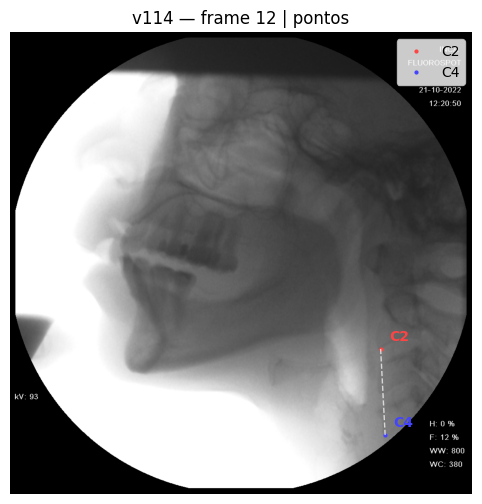

In [12]:
# Verificando... Até a IA erra...
def plot_mask_on_frame(
    mask: np.ndarray,
    video_id: str,
    frame_id: int,
    videos_root: str,
    video_filename_pattern: str = "{video_id}.avi",
    mask_color: tuple = (0, 255, 0),  # BGR — verde lime
    alpha: float = 0.4,
    ax: plt.Axes | None = None,
) -> plt.Axes:

    # Carrega frame
    video_path = str(Path(videos_root) / video_filename_pattern.format(video_id=video_id))
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame_bgr = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Não foi possível ler frame {frame_id} de {video_path}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    h, w = frame_rgb.shape[:2]

    # Normaliza máscara para booleano e redimensiona se necessário
    mask_bin = (np.asarray(mask) > 0)
    if mask_bin.shape != (h, w):
        mask_bin = cv2.resize(
            mask_bin.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST
        ).astype(bool)

    # Constrói overlay colorido
    overlay = frame_rgb.copy()
    color_rgb = (mask_color[2], mask_color[1], mask_color[0])  # BGR → RGB
    overlay[mask_bin] = color_rgb

    blended = cv2.addWeighted(frame_rgb, 1 - alpha, overlay, alpha, 0)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    ax.imshow(blended)
    ax.set_title(f"v{video_id} — frame {frame_id} | máscara")
    ax.axis("off")
    return ax

def plot_points_on_frame(
    points: np.ndarray,
    video_id: str,
    frame_id: int,
    videos_root: str,
    video_filename_pattern: str = "{video_id}.avi",
    point_colors: tuple[str, str] = ("#FF4444", "#4444FF"),  # C2, C4
    point_size: int = 2,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    
    # Carrega frame
    video_path = str(Path(videos_root) / video_filename_pattern.format(video_id=video_id))
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame_bgr = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Não foi possível ler frame {frame_id} de {video_path}")

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6))

    ax.imshow(frame_rgb)

    labels = ["C2", "C4"]
    for i, (pt, color, label) in enumerate(zip(points, point_colors, labels)):
        x, y = float(pt[0]), float(pt[1])
        ax.plot(x, y, "o", color=color, markersize=point_size, label=label)
        ax.annotate(
            label,
            xy=(x, y),
            xytext=(6, 6),
            textcoords="offset points",
            color=color,
            fontsize=10,
            fontweight="bold",
        )

    # Linha conectando C2 e C4
    ax.plot(
        [points[0][0], points[1][0]],
        [points[0][1], points[1][1]],
        "--", color="white", linewidth=1, alpha=0.7,
    )

    ax.legend(loc="upper right")
    ax.set_title(f"v{video_id} — frame {frame_id} | pontos")
    ax.axis("off")
    return ax

# Máscara
#mask = cv2.imread(r"..\relabeling\revisados\v100_f10\Mask.tif", cv2.IMREAD_UNCHANGED)
#ax = plot_mask_on_frame(mask, video_id="100", frame_id=10, videos_root=videos_dir)
#plt.show()

# Pontos
from src.target.points import load_points
points = load_points(r"..\\data\\rotulos\\anotacoes-tecgraf\\batch-3\\VR\\v114_f12")
ax = plot_points_on_frame(points, video_id="114", frame_id=12, videos_root=videos_dir)
plt.show()